In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings # to ignore warnings about depricated functions
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('IPL.csv')

In [5]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [13]:
print(f'rows {df.shape[0]}, colums: {df.shape[1]}')

rows 74, colums: 20


In [19]:
df.isnull().sum() # to get the count of the null values 

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [27]:
# df.groupby('match_winner')['match_winner'].count() 
match_wins=df['match_winner'].value_counts()

Text(0.5, 1.0, 'most matches won by a team ')

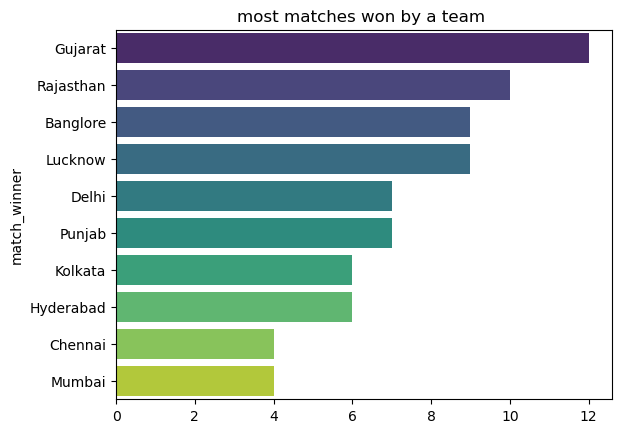

In [32]:
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title("most matches won by a team ")

Text(0.5, 1.0, 'Toss decision Trends')

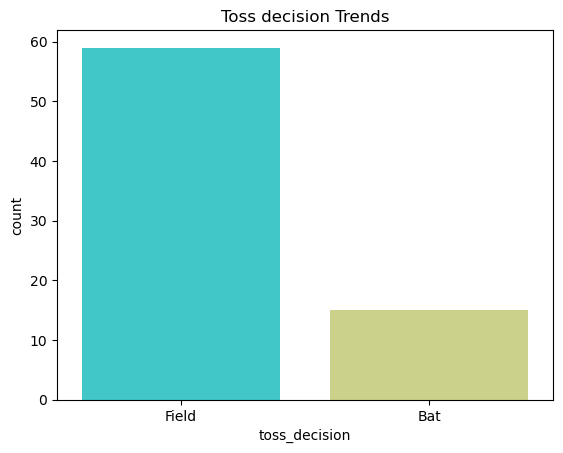

In [42]:
toss_decisions=df['toss_decision'].value_counts()
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title("Toss decision Trends")

In [55]:
df.head(2)
toss_win=df[df['toss_winner']==df['match_winner']]['match_id'].count()
total=df['match_id'].count()
percentage=(toss_win/total)*100
percentage.round(2)

np.float64(48.65)

<Axes: xlabel='won_by', ylabel='count'>

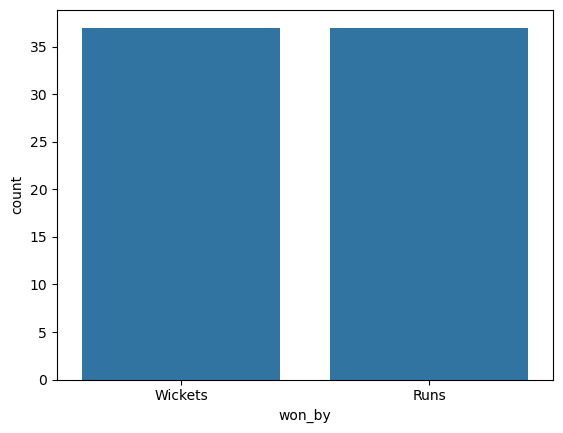

In [64]:
sns.countplot(x=df['won_by'])

<Axes: ylabel='player_of_the_match'>

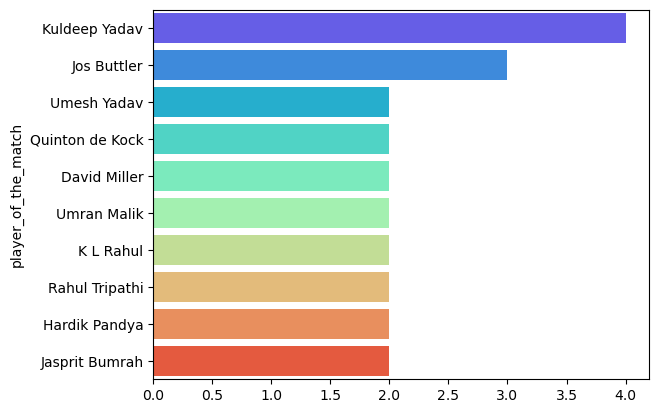

In [76]:
a=df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=a.index,x=a.values,palette='rainbow')

<Axes: ylabel='top_scorer'>

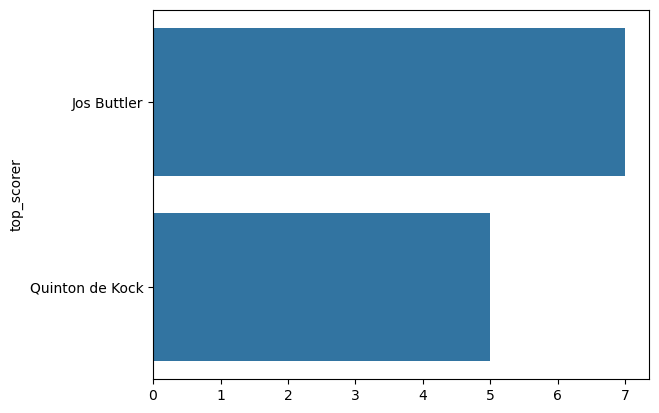

In [79]:
a=df['top_scorer'].value_counts().head(2)
sns.barplot(x=a.values,y=a.index)

In [87]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)

<Axes: xlabel='top_scorer'>

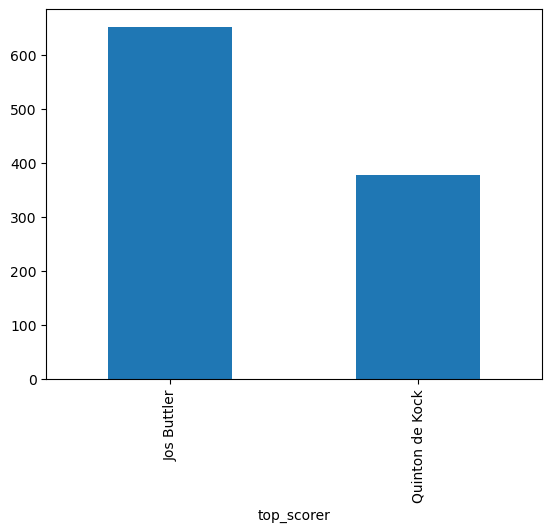

In [89]:
high.plot(kind='bar')

<Axes: ylabel='best_bowling'>

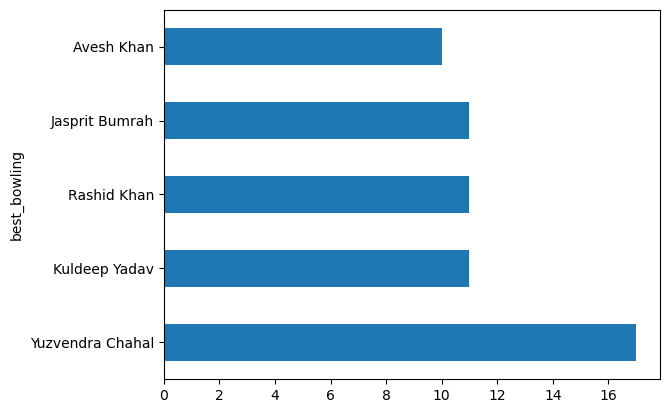

In [96]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)             
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(5)
top_bowlers.plot(kind='barh')

In [100]:
venue_count=df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

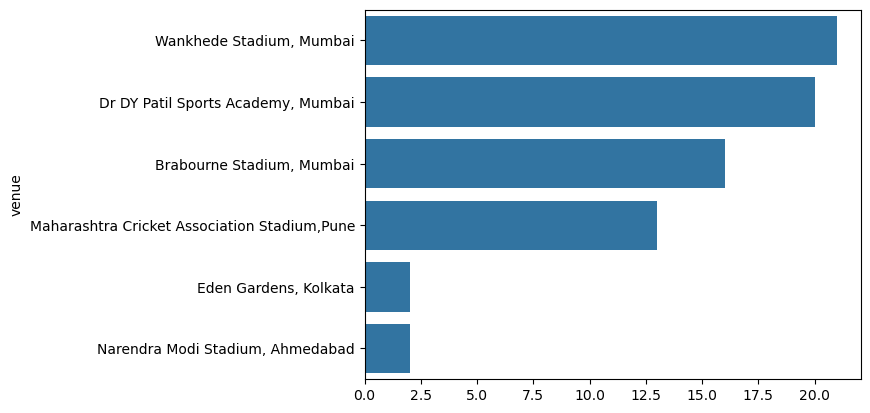

In [102]:
sns.barplot(y=venue_count.index,x=venue_count.values)

<Axes: ylabel='match_winner'>

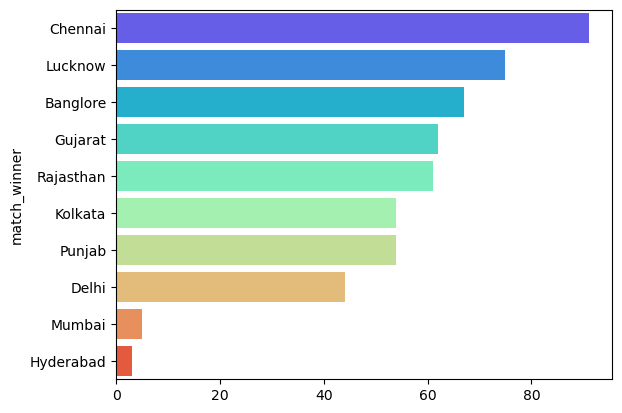

In [121]:
a=df[df['won_by']=="Runs"]
a=a.groupby('match_winner')['margin'].max().sort_values(ascending=False)
sns.barplot(x=a.values, y= a.index,palette="rainbow")

In [123]:
a=df[df['won_by']=="Runs"]
a.sort_values(by='margin',ascending=False).head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
54,55,"May 8,2022","Dr DY Patil Sports Academy, Mumbai",Chennai,Delhi,Group,Delhi,Field,208,6,...,10,Chennai,Runs,91,Devon Conway,Devon Conway,87,Moeen Ali,3--13,3
